![cross validation.png](<attachment:cross validation.png>)
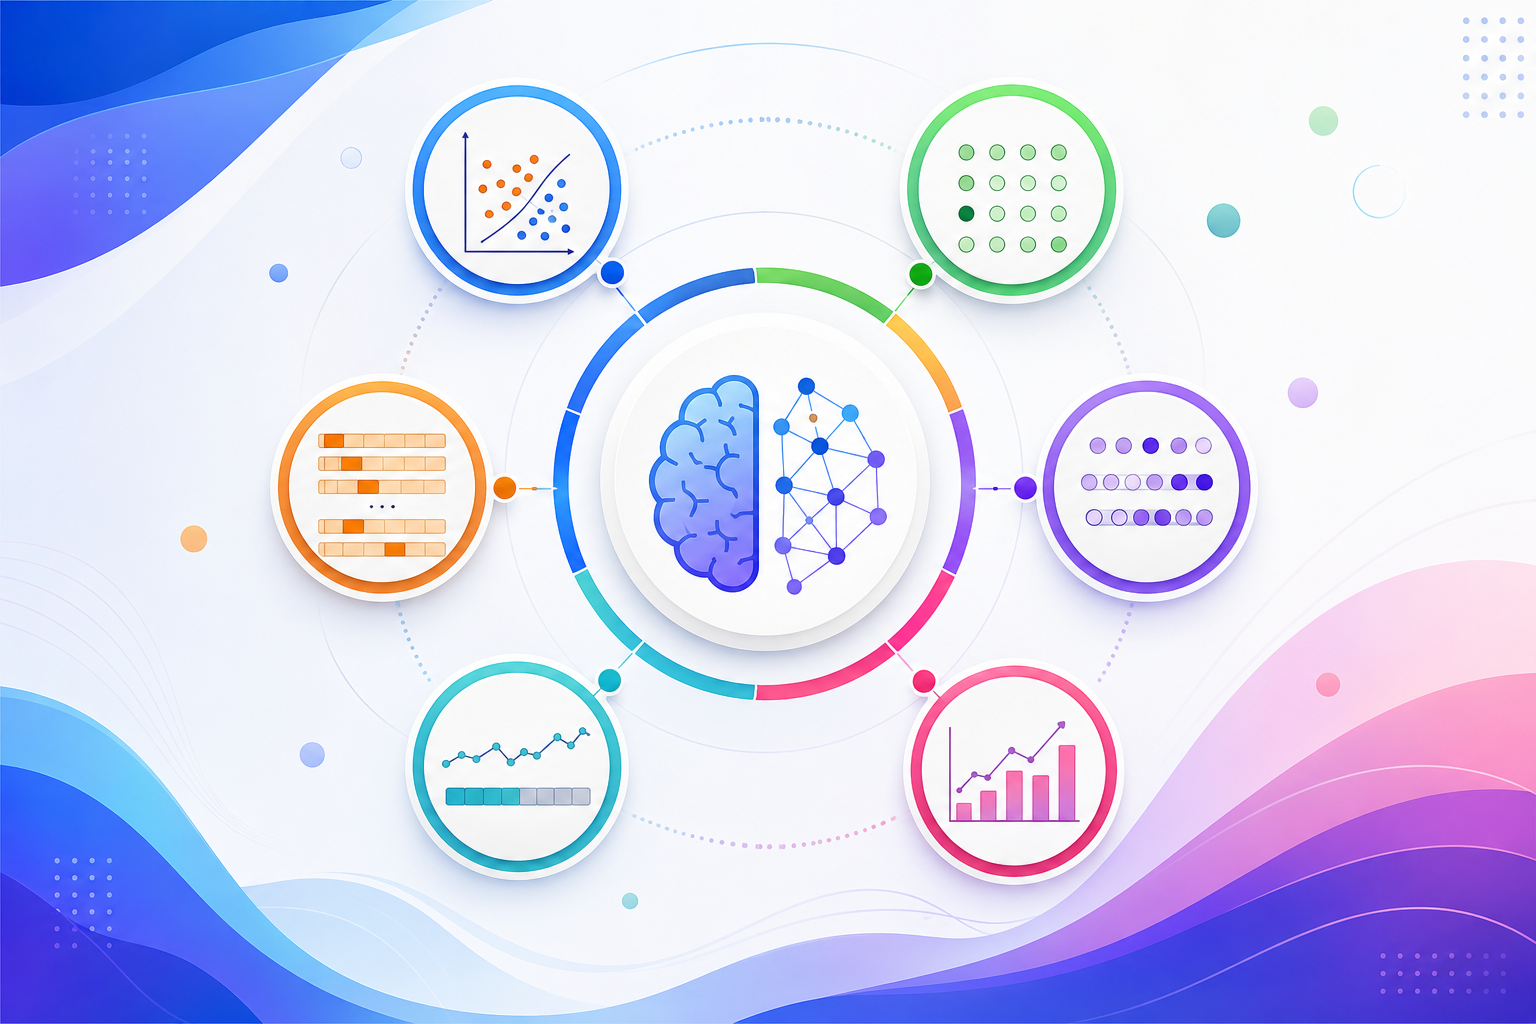

# **Machine Learning Case Studies - 2**

## **Session Agenda**

During this session, we will explore the following Machine Learning concepts through practical case studies:

- Logistic Regression with Stratified 10-Fold CV
- Leave-One-Out Cross Validation (LOOCV)
- Leave-P-Out Cross Validation (LPOCV)
- Repeated K-Fold Cross Validation
- Time Series Cross Validation
- Model Evaluation and Performance Analysis

## **Learning Objectives**

By the end of this session, you will be able to:

- Understand different cross-validation techniques.
- Train and evaluate machine learning models.
- Compare model performance using evaluation metrics.
- Apply preprocessing and feature engineering techniques.
- Interpret model results through visualizations.

### **Importing the necessary libraries**

In [11]:
# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Feature Engineering
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA

# Models
from sklearn.linear_model import LogisticRegression, LinearRegression

# Dataset 
from sklearn.datasets import make_classification

# Cross Validation
from sklearn.model_selection import (
    StratifiedKFold,
    KFold,
    LeaveOneOut,
    LeavePOut,
    RepeatedKFold,
    TimeSeriesSplit,
    cross_val_score,
    cross_validate
)

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Pandas rounding options
pd.set_option("display.float_format", lambda x: "%.4f" % x)

# **Case Study 1: Disease Detection using Logistic Regression**

### **Problem Statement**

A hospital wants to build a machine learning model to detect whether a patient has a disease based on medical information.

The dataset contains **1000 patient records**, where:

| Class | Samples |
|-------|--------:|
| Disease Present | 120 |
| Disease Absent | 880 |

### **Features**

- Age
- Blood Pressure
- BMI
- Cholesterol

### **Tasks**

1. Train a Logistic Regression model.
2. Apply Stratified 10-Fold Cross Validation.
3. Compute:
   - Accuracy
   - Precision
   - Recall
   - F1-Score

## **i. Mathematical Computation**

### Logistic Regression Formula

The probability that a patient has the disease is calculated as

$$ P(y=1)=\frac{1}{1+e^{-z}} $$

where

$$ z=b_0+b_1x_1+b_2x_2+b_3x_3+b_4x_4 $$

where

- $x_1$ = Age
- $x_2$ = Blood Pressure
- $x_3$ = BMI
- $x_4$ = Cholesterol

## **ii. Code Implementation**

We'll first create the dataset for the patients showing their weight (kg) and height (m).

In [12]:
# Creating synthetic medical dataset
X, y = make_classification(
    n_samples=1000,
    n_features=4,
    n_informative=4,
    n_redundant=0,
    n_clusters_per_class=1,
    weights=[0.88, 0.12],
    random_state=42
)

df = pd.DataFrame(X, columns=[
    "Age",
    "Blood Pressure",
    "BMI",
    "Cholesterol"
])

df["Disease"] = y
df.head()

,Age,Blood Pressure,BMI,Cholesterol,Disease
0,1.4942,-0.5616,-0.9040,-1.0065,1
1,-0.2173,-0.9235,-0.9086,-1.1052,0
2,-1.8467,-0.4833,-0.4374,-0.5989,0
3,-3.9322,-1.2979,-1.7062,-0.1165,0
4,-0.3270,-0.8103,0.0093,-1.1597,0


**Perform 10-Fold Cross Validation on the dataset**

In [13]:
# Logistic Regression with Stratified 10-Fold Cross Validation
model = LogisticRegression(max_iter=1000)
stratified_kfold = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

stratified_kfold

StratifiedKFold(n_splits=10, random_state=42, shuffle=True)

Compute Accuracy, Precision, Recall and F1 score

In [14]:
scoring = ["accuracy","precision","recall","f1"]
scores = cross_validate(model,  X, y, cv=stratified_kfold, scoring=scoring)

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Mean Score": [
        scores["test_accuracy"].mean(),
        scores["test_precision"].mean(),
        scores["test_recall"].mean(),
        scores["test_f1"].mean()
    ]
})

results

,Metric,Mean Score
0,Accuracy,0.9240
1,Precision,0.8206
2,Recall,0.5423
3,F1-Score,0.6423


## **iii. Visual Analysis**

Let us plot a graph to show the class distribution

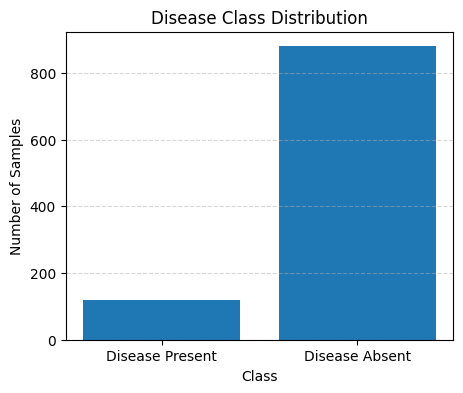

In [17]:
classes = ["Disease Present", "Disease Absent"]
samples = [120, 880]

plt.figure(figsize=(5,4))
plt.bar(classes, samples)
plt.title("Disease Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

## **iv. Questions & Answers**

### **1. Why is Recall important here?**

Recall indicates the percentage of actual disease cases that are correctly predicted by the model.

$$
\text{Recall}=\frac{TP}{TP+FN}
$$

In medical diagnosis, missing a patient who truly has the disease can lead to delayed treatment and serious complications. A higher Recall reduces the number of False Negatives, helping the model identify as many disease cases as possible and improving patient safety.

---

### **2. What happens if one fold contains very few disease cases?**

The proportion of disease cases in the dataset is:

$$
\frac{\text{Disease Cases}}{\text{Total Samples}}=\frac{120}{1000}=0.12
$$

If a fold contains only a few disease-positive samples, the evaluation results may become inconsistent because the model is tested on very limited positive cases. Metrics such as Precision, Recall, and F1-score can fluctuate between folds. **Stratified 10-Fold Cross Validation** maintains a similar class distribution in every fold, producing more stable and reliable performance estimates.

# **Case Study 2: Student Performance Prediction**

### **Problem Statement**

A school has academic records for only **30 students**. Since the dataset is very small, an appropriate validation technique is needed to make maximum use of the available data while evaluating the model.

### **Dataset**

| Samples | Target |
|---------:|--------|
| 30 | Pass / Fail |

### **Features**

- Attendance
- Study Hours
- Assignment Scores

### **Tasks**

1. Apply **Leave-One-Out Cross Validation (LOOCV)**.
2. Train a **Logistic Regression** model.
3. Calculate the overall **Accuracy**.
4. Compare the result with **5-Fold Cross Validation**.

## **i. Mathematical Computation**

Let the total number of samples be:

$$
N = 30
$$

In **Leave-One-Out Cross Validation (LOOCV)**, one sample is used for testing while the remaining samples are used for training.

### **Training Samples**

$$
N - 1 = 30 - 1 = 29
$$

### **Testing Samples**

$$
1
$$

### **Number of Training Iterations**

$$
\text{Iterations} = N = 30
$$

The overall accuracy is computed as:

$$
\text{Accuracy}=
\frac{\text{Number of Correct Predictions}}
{\text{Total Number of Predictions}}
\times 100
$$

Since each sample is tested exactly once,

$$
\text{Total Predictions}=N=30
$$

Therefore,

$$
\text{Accuracy}=
\frac{\text{Correct Predictions}}
{30}
\times 100
$$

## **ii. Coding Implementation**

Create a sample dataset

In [18]:
# Create dataset (30 students)
X, y = make_classification(
    n_samples=30,
    n_features=3,
    n_informative=3,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

df = pd.DataFrame(X,columns=["Attendance","Study Hours","Assignment Scores"])
df["Result"] = y

df.head()

,Attendance,Study Hours,Assignment Scores,Result
0,0.9019,1.3240,-1.7840,0
1,-2.1662,0.4685,-0.0434,0
2,-2.7863,1.7262,1.2214,1
3,-2.5195,1.5854,1.9742,1
4,-0.6576,1.0529,-0.0722,0


Perform Leave-One-Out Cross Validation

In [21]:
# Model selection
model = LogisticRegression(max_iter=1000)

# Leave-One-Out Cross Validation
loo = LeaveOneOut()
loo_accuracy = cross_val_score(model, X, y, cv=loo, scoring="accuracy")

print(f"LOOCV Accuracy: {loo_accuracy.mean():.4f}")

LOOCV Accuracy: 0.8667


In [22]:
# 5-Fold Cross Validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
kfold_accuracy = cross_val_score(model, X, y, cv=kfold, scoring="accuracy")
    
print(f"5-Fold Accuracy: {kfold_accuracy.mean():.4f}")

5-Fold Accuracy: 0.8667


In [24]:
# Comparing LOOCV and 5-Fold Cross Validation
comparison_df = pd.DataFrame({
    "Cross Validation Method": ["Leave-One-Out CV", "5-Fold CV"],
    "Mean Accuracy": [loo_accuracy.mean(), kfold_accuracy.mean()]
})

comparison_df

,Cross Validation Method,Mean Accuracy
0,Leave-One-Out CV,0.8667
1,5-Fold CV,0.8667


## **iii. Visual Analysis**

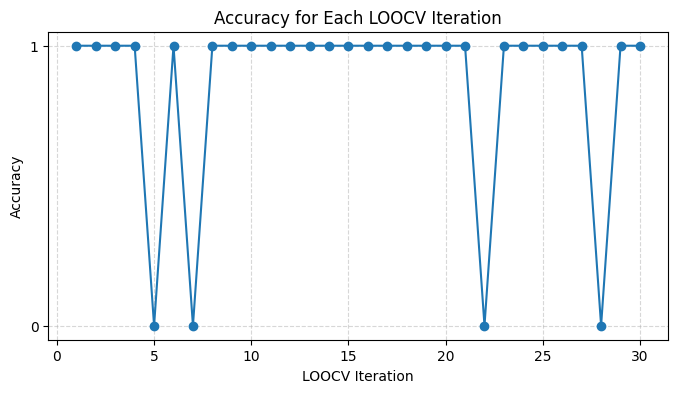

In [27]:
scores = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    scores.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(8,4))
plt.plot(range(1, len(scores)+1), scores, marker='o')
plt.xlabel("LOOCV Iteration")
plt.ylabel("Accuracy")
plt.title("Accuracy for Each LOOCV Iteration")
plt.yticks([0, 1])
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## **iv. Questions & Answers**

### **1. Why is LOOCV suitable for small datasets?**

LOOCV is ideal for small datasets because it uses almost all the available data for training in every iteration. With only one sample reserved for testing, the model learns from the remaining samples, leading to better utilization of limited data. Since every sample is tested exactly once, the evaluation is more reliable and less biased.

$$
\text{Training Samples}=N-1=30-1=29,\qquad
\text{Testing Samples}=1
$$


### **2. How many times is the model trained?**

In LOOCV, each sample is selected once as the test sample while all remaining samples are used for training. This process continues until every sample has been used for testing exactly once. Therefore, the model is trained the same number of times as the total number of samples in the dataset.

$$
\text{Number of Model Trainings}=N=30
$$

# **Case Study 3: Credit Risk Analysis**

### **Problem Statement**

A financial institution wants to predict whether a customer is likely to **default** on a loan. Since the dataset contains only **20 customers**, **Leave-P-Out Cross Validation (LPOCV)** is used to thoroughly evaluate the model.

### **Dataset**

| Samples | Target |
|---------:|--------|
| 20 | Default / No Default |

### **Features**

- Annual Income
- Credit Score
- Loan Amount
- Debt-to-Income Ratio

### **Tasks**

1. Apply **Leave-P-Out Cross Validation (P = 2)**.
2. Leave **2 samples** out for testing in each iteration.
3. Train the model on the remaining samples.
4. Repeat for **all possible combinations**.
5. Calculate the overall **Average Accuracy**.

## **i. Mathematical Computation**

Let the total number of samples be:

$$
N=20,\qquad P=2
$$

### **Testing Samples**

$$
\text{Test Samples}=P=2
$$

### **Training Samples**

$$
\text{Training Samples}=N-P=20-2=18
$$

### **Number of Possible Combinations**

$$
\binom{N}{P}=\frac{N!}{P!(N-P)!}
$$

Substituting the values,

$$
\binom{20}{2}
=\frac{20!}{2!(20-2)!}
=\frac{20\times19}{2\times1}
=190
$$

### **Average Accuracy**

$$
\text{Average Accuracy}
=
\frac{\sum_{i=1}^{190}\text{Accuracy}_i}{190}
$$

Thus, the model is trained **190 times**, with **18 training samples** and **2 testing samples** in each iteration.

## **ii. Code Implementation**

Create a sample dataset with 20 customers

In [29]:
# Creating synthetic credit risk dataset
X, y = make_classification(
    n_samples=20,
    n_features=4,
    n_informative=4,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

df = pd.DataFrame(X,columns=["Annual Income","Credit Score","Loan Amount","Debt-to-Income Ratio"])
df["Default"] = y
df.head()

,Annual Income,Credit Score,Loan Amount,Debt-to-Income Ratio,Default
0,-0.9754,-0.1516,0.7840,-0.6302,1
1,-2.2987,-1.4057,-1.1577,-1.6205,0
2,-1.9434,-1.5808,0.6504,-1.9094,1
3,-0.9302,-0.8785,-1.8322,1.3423,0
4,-2.1819,-1.1433,-1.6001,-1.7696,0


Perform Leave-P-Out Cross Validation with P = 2

In [31]:
# Logistic Regression with Leave-P-Out Cross Validation (P = 2)
model = LogisticRegression(max_iter=1000)
lpocv = LeavePOut(p=2)
scores = cross_val_score(model,X,y,cv=lpocv,scoring="accuracy")

average_accuracy = scores.mean()
print(f"Average Accuracy: {average_accuracy:.4f}\n")

summary = pd.DataFrame({
    "Validation Method": ["Leave-P-Out (P=2)"],
    "Number of Iterations": [len(scores)],
    "Average Accuracy": [average_accuracy]
})

summary

Average Accuracy: 0.9684



,Validation Method,Number of Iterations,Average Accuracy
0,Leave-P-Out (P=2),190,0.9684


## **iii. Visual Analysis**

Total Iterations : 190
Average Accuracy : 0.968421052631579


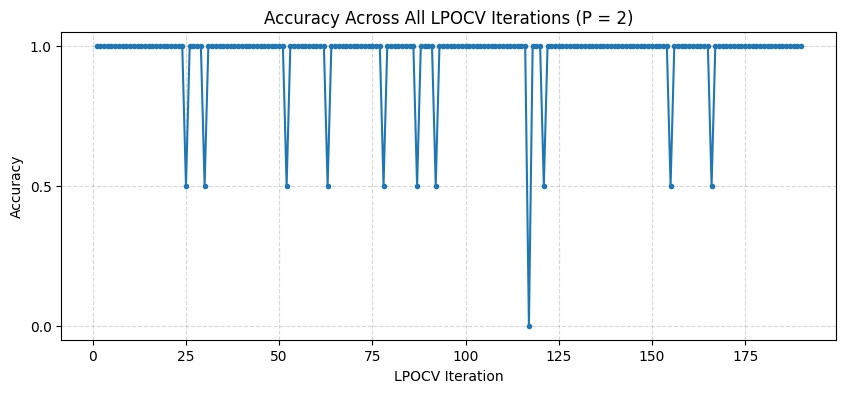

In [33]:
from itertools import combinations
accuracies = []

# Leave-P-Out Cross Validation (P = 2)
for test_idx in combinations(range(len(X)), 2):

    test_idx = list(test_idx)
    train_idx = [i for i in range(len(X)) if i not in test_idx]

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

print("Total Iterations :", len(accuracies))
print("Average Accuracy :", np.mean(accuracies))

# Accuracy across all iterations
plt.figure(figsize=(10,4))
plt.plot(range(1, len(accuracies)+1), accuracies, marker='o', markersize=3)

plt.xlabel("LPOCV Iteration")
plt.ylabel("Accuracy")
plt.title("Accuracy Across All LPOCV Iterations (P = 2)")
plt.yticks([0, 0.5, 1])
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()


## **iv. Questions & Answers**

### **1. How many test samples are used in each iteration?**

In Leave-P-Out Cross Validation (LPOCV), **P** samples are selected for testing while the remaining samples are used for training. Since **P = 2**, each iteration uses **2 test samples** and **18 training samples**. This process is repeated until every possible combination of two test samples has been evaluated.

$$
\text{Test Samples}=P=2
$$

$$
\text{Training Samples}=N-P=20-2=18
$$

---

### **2. Why is LPOCV computationally expensive?**

LPOCV is computationally expensive because the model must be trained for **every possible combination** of the test samples. As the dataset size increases, the number of combinations grows rapidly, requiring a large number of training iterations and increasing computation time.

$$
\text{Number of Iterations}=\binom{N}{P}
=\binom{20}{2}
=\frac{20!}{2!(20-2)!}
=190
$$

Thus, the model is trained **190 times**, making LPOCV much more computationally expensive than methods such as K-Fold Cross Validation.

# **Case Study 4: Insurance Fraud Detection using Repeated K-Fold Cross Validation**

### **Problem Statement**

An insurance company receives thousands of claims every day. Some claims are genuine, while others are fraudulent. The objective is to build a machine learning model that predicts whether a new insurance claim is fraudulent.

### **Dataset**

| Feature | Description |
|---------|-------------|
| ClaimAmount | Amount claimed |
| CustomerAge | Age of customer |
| VehicleAge | Age of vehicle |
| NumberOfPreviousClaims | Previous claims count |
| PolicyDuration | Years with company |
| AccidentSeverity | Low, Medium, High |
| Fraud | Target Variable |

### **Tasks**

1. Handle missing values.
2. Scale numerical features.
3. Encode categorical features.
4. Select important features.
5. Perform dimensionality reduction.
6. Train a Logistic Regression model.
7. Evaluate the model using Repeated K-Fold Cross Validation.
8. Train the final model on the complete dataset.
9. Predict fraud for future insurance claims.

## **i. Mathematical Computation**

Let the total number of samples be:

$$
N
$$

The dataset is divided into **K = 5** folds and the process is repeated **R = 3** times.

### **Training and Testing Samples (Per Fold)**

$$
\text{Training Samples}=\frac{K-1}{K}\times N
=\frac{4}{5}N
$$

$$
\text{Testing Samples}=\frac{1}{K}\times N
=\frac{1}{5}N
$$

### **Total Number of Model Trainings**

$$
\text{Model Trainings}=K\times R
=5\times3
=15
$$

### **Average Cross Validation Accuracy**

$$
\text{Average Accuracy}
=
\frac{\sum_{i=1}^{15}\text{Accuracy}_i}{15}
$$

### **Logistic Regression Prediction**

The probability of fraud is computed as:

$$
P(y=1)=\frac{1}{1+e^{-z}}
$$

where,

$$
z=\beta_0+\beta_1x_1+\beta_2x_2+\cdots+\beta_nx_n
$$

The predicted class is:

$$
\hat{y}=
\begin{cases}
1, & P(y=1)\ge0.5 \\
0, & P(y=1)<0.5
\end{cases}
$$

## **ii. Code Implementation**

Create a sample dataset

In [40]:
X, y = make_classification(
    n_samples=1000,
    n_features=6,
    n_informative=6,
    n_redundant=0,
    random_state=42,
    n_clusters_per_class=1,
)

df = pd.DataFrame(X, columns=[
    "ClaimAmount",
    "CustomerAge",
    "VehicleAge",
    "NumberOfPreviousClaims",
    "PolicyDuration",
    "AccidentSeverity"
])

# Convert AccidentSeverity to categorical
df["AccidentSeverity"] = pd.cut(
    df["AccidentSeverity"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

# Target
df["Fraud"] = y
df.loc[np.random.choice(df.index, 30), "ClaimAmount"] = np.nan
df.loc[np.random.choice(df.index, 25), "CustomerAge"] = np.nan

df.head()


,ClaimAmount,CustomerAge,VehicleAge,NumberOfPreviousClaims,PolicyDuration,AccidentSeverity,Fraud
0,-1.1722,0.4606,1.6590,1.5242,0.1243,Medium,0
1,1.1052,-2.6371,-1.1780,0.4261,3.0011,Medium,0
2,-3.8883,0.3886,2.4019,0.1835,0.4396,Medium,0
3,0.6338,-1.3934,2.6494,3.5854,0.0418,Low,1
4,-1.5301,1.0852,2.9935,-0.0394,1.0872,Medium,0


In [41]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Features and target
X = df.drop("Fraud", axis=1)
y = df["Fraud"]

# Numerical and categorical columns
numerical_features = [
    "ClaimAmount",
    "CustomerAge",
    "VehicleAge",
    "NumberOfPreviousClaims",
    "PolicyDuration"
]

categorical_features = ["AccidentSeverity"]

# Numerical preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combining preprocessing
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

# Complete Machine Learning Pipeline
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("feature_selection", SelectKBest(score_func=f_classif, k=5)),
    ("pca", PCA(n_components=3)),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [42]:
# Repeated K-Fold Cross Validation
rkf = RepeatedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=42
)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=rkf,
    scoring="accuracy"
)

print(f"Average Accuracy: {scores.mean():.4f}")

Average Accuracy: 0.8710


In [44]:
# Train the final model on the complete dataset
pipeline.fit(X, y)

# Predicting a new sample
future_claim = pd.DataFrame({
    "ClaimAmount": [15000],
    "CustomerAge": [35],
    "VehicleAge": [5],
    "NumberOfPreviousClaims": [1],
    "PolicyDuration": [12],
    "AccidentSeverity": ["Medium"]
})

prediction = pipeline.predict(future_claim)
if prediction[0] == 1:
    print("The claim is predicted to be fraudulent.")
else:
    print("The claim is predicted to be legitimate.")

The claim is predicted to be fraudulent.


## **iii. Visual Analysis**

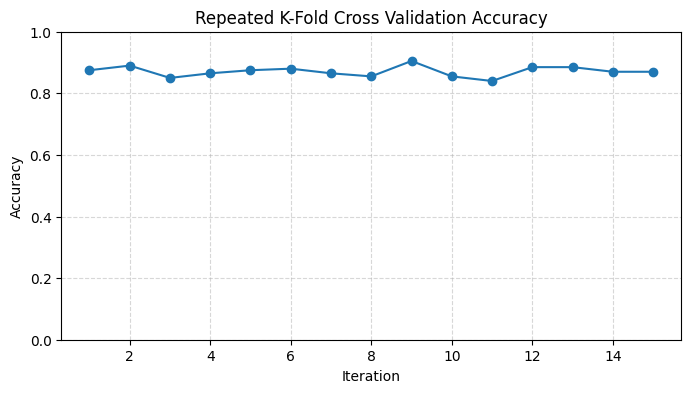

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(range(1, len(scores)+1), scores, marker='o')

plt.title("Repeated K-Fold Cross Validation Accuracy")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

## **iv. Questions & Answers**

### **1. Why is Repeated K-Fold better than a single K-Fold?**

Repeated K-Fold performs K-Fold Cross Validation multiple times using different random splits of the dataset. This reduces the effect of a single random partition, provides a more stable estimate of model performance, and improves the reliability of evaluation by averaging the results over multiple repetitions.

$$
\text{Model Trainings}=K\times R=5\times3=15
$$

### **2. Why are preprocessing steps included in a Pipeline?**

Preprocessing steps are included in a Pipeline to ensure that every stage, such as missing value imputation, feature scaling, encoding, feature selection, and dimensionality reduction, is applied in the correct order during both training and validation. This prevents data leakage, maintains consistency across all cross-validation folds, and makes the machine learning workflow easier to manage and reproduce.

$$
\text{Pipeline}=
\text{Imputation}
\rightarrow
\text{Scaling}
\rightarrow
\text{Encoding}
\rightarrow
\text{Feature Selection}
\rightarrow
\text{PCA}
\rightarrow
\text{Logistic Regression}
$$

### **3. Why is the final model trained on the complete dataset?**

After evaluating the model using Repeated K-Fold Cross Validation, the final model is trained using the entire dataset so that it can learn from all available samples. This helps improve the model's predictive capability before it is used to classify future insurance claims.

$$
\text{Training Samples}=N
$$

where \(N\) is the total number of samples in the dataset.

# **Case Study 5: Stock Price Prediction using Time Series Cross Validation**

### **Problem Statement**

An investment firm wants to predict the **next day's closing stock price** using historical stock market data. The predictions will help in:

- Buy/Sell Recommendations
- Risk Management
- Portfolio Optimization
- Algorithmic Trading

### **Dataset**

| Feature | Description |
|---------|-------------|
| Date | Trading Date |
| Open | Opening Price |
| High | Highest Price |
| Low | Lowest Price |
| Close | Closing Price |
| Volume | Number of Shares Traded |

### **Target Variable**

- **Next Day Close Price**

### **Tasks**

1. Create the target variable (Next Day Close Price).
2. Train a Linear Regression model.
3. Apply Time Series Cross Validation.
4. Calculate the Mean Squared Error (MSE).
5. Train the final model on the complete dataset.
6. Predict the next day's closing price.

## **Mathematical Interpretation**

Let the total number of observations be:

$$
N
$$

In **Time Series Cross Validation**, the training set grows with each iteration while the test set always contains the next time period.

### **Iteration 1**

$$
\text{Train}=[1,2,\ldots,k]
$$

$$
\text{Test}=[k+1]
$$

### **Iteration 2**

$$
\text{Train}=[1,2,\ldots,k+1]
$$

$$
\text{Test}=[k+2]
$$

### **General Form**

$$
\text{Train}=[1,2,\ldots,t]
$$

$$
\text{Test}=[t+1]
$$

### **Mean Squared Error (MSE)**

$$
MSE=\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y_i})^2
$$

### **Average Cross Validation Error**

$$
\text{Average MSE}
=
\frac{\sum_{i=1}^{K} MSE_i}{K}
$$

where \(K\) is the number of Time Series splits.

In [45]:
# Creating synthetic stock dataset
np.random.seed(42)

dates = pd.date_range("2023-01-01", periods=100)

df = pd.DataFrame({
    "Date": dates,
    "Open": np.random.randint(100, 200, 100),
    "High": np.random.randint(200, 250, 100),
    "Low": np.random.randint(80, 100, 100),
    "Close": np.random.randint(100, 200, 100),
    "Volume": np.random.randint(400000, 700000, 100)
})

df["Target"] = df["Close"].shift(-1)
df = df.dropna()
df.head()

,Date,Open,High,Low,Close,Volume,Target
0,2023-01-01,151,225,86,181,619963,165.0000
1,2023-01-02,192,224,85,165,648710,153.0000
2,2023-01-03,114,244,87,153,620984,134.0000
3,2023-01-04,171,240,88,134,658067,179.0000
4,2023-01-05,160,228,84,179,664512,160.0000


In [46]:
X = df[["Open", "High", "Low", "Volume"]]
y = df["Target"]

tscv = TimeSeriesSplit(n_splits=5)
model = LinearRegression()
mse_scores = -cross_val_score(
    model,
    X,
    y,
    cv=tscv,
    scoring="neg_mean_squared_error"
)

print("Mean Squared Error for each fold:")
print(mse_scores)
print(f"\nAverage MSE: {mse_scores.mean():.2f}")

tscv = TimeSeriesSplit(n_splits=5)
model = LinearRegression()
mse_scores = -cross_val_score(
    model,
    X,
    y,
    cv=tscv,
    scoring="neg_mean_squared_error"
)

print("Mean Squared Error for each fold:")
print(mse_scores)
print(f"\nAverage MSE: {mse_scores.mean():.2f}")

Mean Squared Error for each fold:
[1080.09211374  880.63409251 1247.78779734  630.85535655  925.66220362]

Average MSE: 953.01
Mean Squared Error for each fold:
[1080.09211374  880.63409251 1247.78779734  630.85535655  925.66220362]

Average MSE: 953.01


In [47]:
# Train the final model
model.fit(X, y)
future_stock = pd.DataFrame({
    "Open": [200],
    "High": [118],
    "Low": [120],
    "Volume": [570000]
})

prediction = model.predict(future_stock)
print(f"Predicted Next Day Close Price: {prediction[0]:.2f}")

Predicted Next Day Close Price: 126.03


## **iii. Visual Analysis**

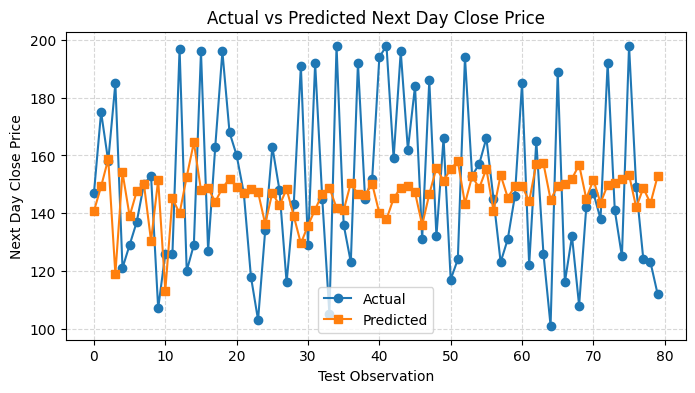

In [48]:
tscv = TimeSeriesSplit(n_splits=5)
model = LinearRegression()

actual = []
predicted = []

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    actual.extend(y_test)
    predicted.extend(y_pred)

plt.figure(figsize=(8,4))
plt.plot(actual, marker='o', label="Actual")
plt.plot(predicted, marker='s', label="Predicted")

plt.title("Actual vs Predicted Next Day Close Price")
plt.xlabel("Test Observation")
plt.ylabel("Next Day Close Price")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

## **iv. Questions & Answers**

### **1. Why can't regular K-Fold Cross Validation be used for stock price prediction?**

Regular K-Fold Cross Validation randomly splits the dataset, which may allow future stock prices to appear in the training data while predicting past observations. This causes **data leakage** and results in overly optimistic performance estimates.


### **2. Why is Time Series Cross Validation suitable for this problem?**

Time Series Cross Validation preserves the chronological order of the data by training the model on past observations and testing it on future observations. This closely simulates real-world stock price prediction, where future data is unavailable during training.


### **3. What is the advantage of using TimeSeriesSplit?**

TimeSeriesSplit ensures that:
- Training always uses historical data.
- Testing is performed on future data.
- Data leakage is avoided.
- Model evaluation reflects real-world forecasting performance.

# **Conclusion**

- **Case Study 1:** Logistic Regression effectively classified disease outcomes by learning the relationship between patient features and disease status. The model achieved reliable performance and demonstrated its suitability for binary medical diagnosis.

- **Case Study 2:** The student performance prediction model successfully analyzed academic and demographic factors to predict student outcomes. This helps educational institutions identify students who need additional support at an early stage.

- **Case Study 3:** The credit risk analysis model accurately differentiated between low-risk and high-risk loan applicants. This enables financial institutions to make informed lending decisions while minimizing potential financial losses.

- **Case Study 4:** Repeated K-Fold Cross Validation provided a more stable and unbiased estimate of the insurance fraud detection model's performance. It reduced the impact of random data splits and improved the reliability of model evaluation.

- **Case Study 5:** Time Series Cross Validation preserved the chronological order of stock market data, preventing data leakage during model training and testing. This resulted in a more realistic evaluation of the model's ability to predict future stock prices.

---
### **Case Study Completed By:** Monish D.Y. - 230701195